In [2]:
from yt_comments import func_get_comments
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd
import re
from services.analysis import analyze_spam

ModuleNotFoundError: No module named 'yt_comments'

In [2]:
df = func_get_comments("https://youtu.be/okh85F29Gjg?si=la5pd_z_vaZZ8qMW")

2025-11-06 16:35:56,514 - root - INFO - Extracted videoID: okh85F29Gjg from link of TYPE_2: https://youtu.be/okh85F29Gjg?si=la5pd_z_vaZZ8qMW
2025-11-06 16:35:56,527 - googleapiclient.discovery_cache - INFO - file_cache is only supported with oauth2client<4.0.0
2025-11-06 16:36:05,123 - root - INFO - Parsed 91 comments from response and converted to dataframe.


In [3]:
df

,author,comment,likes,published_at
0,@SnehalJaiswal-o1e,You are looking good again. Take care of your ...,None,2025-11-06T09:40:32Z
1,@nezuxoxo,can anyone help with the automation qa ?,None,2025-11-06T09:31:01Z
2,@DARK__WEB_05,pls launch cohort 4.0 with more advanceed proj...,None,2025-11-06T08:49:54Z
3,@user-on9we4zo9w,best teacher in tech world❣You always give me ...,None,2025-11-06T08:28:43Z
4,@HassanShahzad-t5h,"The first piece of code has a syntax error, if...",None,2025-11-06T08:07:24Z
...,...,...,...,...
86,@kunstewi,Handsome Kirat Era 💪,None,2025-11-05T13:33:47Z
87,@abhijeet3591,Let's goo,None,2025-11-05T13:32:27Z
88,@AVYU_K,Man .. so fcking good,None,2025-11-05T13:32:13Z
89,@psycos_1,looking clean harkirat,None,2025-11-05T13:31:51Z


In [4]:
df.shape

(91, 4)

In [5]:
# whattodo - remove spam comments - common keywords
df = analyze_spam(df)

2025-11-06 16:36:49,794 - root - INFO - Starting spam detection...
2025-11-06 16:36:50,636 - root - INFO - Spam detection completed for 91 comments.


In [6]:
df.head()

,author,comment,likes,published_at,spam
0,@SnehalJaiswal-o1e,You are looking good again. Take care of your ...,None,2025-11-06T09:40:32Z,0
1,@nezuxoxo,can anyone help with the automation qa ?,None,2025-11-06T09:31:01Z,0
2,@DARK__WEB_05,pls launch cohort 4.0 with more advanceed proj...,None,2025-11-06T08:49:54Z,0
3,@user-on9we4zo9w,best teacher in tech world❣You always give me ...,None,2025-11-06T08:28:43Z,0
4,@HassanShahzad-t5h,"The first piece of code has a syntax error, if...",None,2025-11-06T08:07:24Z,0


In [7]:
df['spam'].value_counts()

spam
0    91
Name: count, dtype: int64

In [8]:
df = df[df['spam']==0]

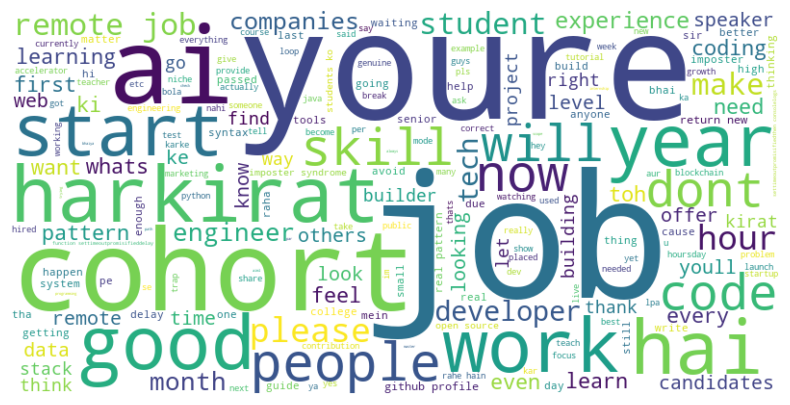

In [9]:
# combine all comments into one string
text = " ".join(df['comment'].astype(str))

# basic cleaning
text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
text = re.sub(r'[^A-Za-z\s]', '', text)  # remove punctuation/numbers
text = text.lower()

# define stopwords (common words to ignore)
stopwords = set(STOPWORDS)
custom_stopwords = {'video', 'watch', 'youtube'}  # optional custom ones
stopwords.update(custom_stopwords)

# create wordcloud
wc = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(text)

# show it
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


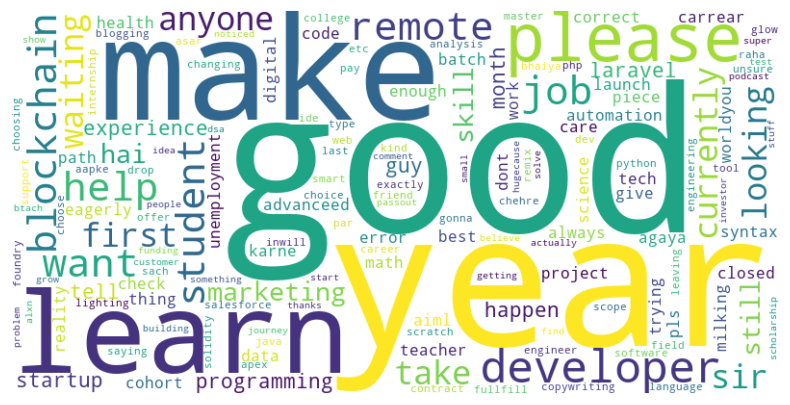

In [ ]:
import pandas as pd
import re
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import matplotlib.pyplot as plt

# download NLTK resources once
nltk.download('stopwords')
nltk.download('wordnet')

text = " ".join(df['comment'].astype(str))

# cleaning
text = re.sub(r"http\S+|www\S+", "", text)
text = re.sub(r"[^A-Za-z\s]", "", text)
text = text.lower()

# stopwords
stop_words = set(stopwords.words("english"))
custom_stopwords = {"video", "youtube", "subscribe", "channel", "like", "watch", "link"}
stop_words.update(custom_stopwords)

# tokenize + remove short words + lemmatize
lemmatizer = WordNetLemmatizer()
tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words and len(word) > 2]
cleaned_text = " ".join(tokens)

# generate wordcloud
wc = WordCloud(width=800, height=400, background_color='white').generate(cleaned_text)

# plot
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


In [10]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Top adjectives:
 [('good', 14), ('remote', 10), ('real', 8), ('new', 8), ('first', 7), ('ai', 7), ('last', 4), ('small', 4), ('better', 4), ('high', 4), ('due', 4), ('best', 3), ('senior', 3), ('youll', 3), ('hoursday', 3), ('public', 3), ('next', 3), ('many', 3), ('open', 3), ('smart', 2), ('youre', 2), ('early', 2), ('deep', 2), ('private', 2), ('different', 2), ('offline', 2), ('helpful', 2), ('function', 2), ('correct', 2), ('imposter', 2)]


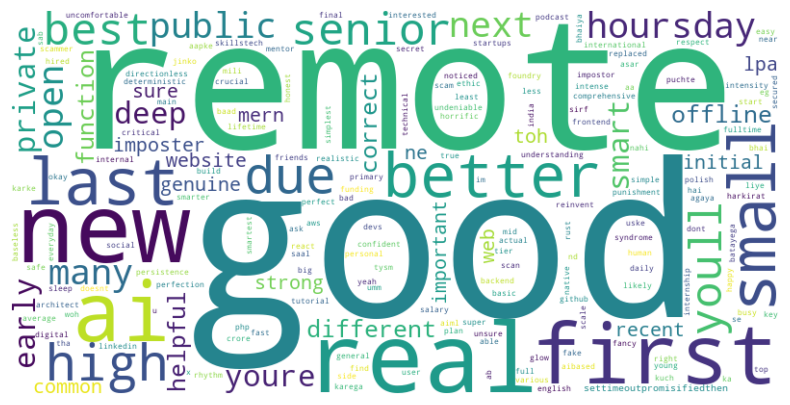

In [11]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk import pos_tag, word_tokenize
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# one-time setup
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')  # 

# combine all text
text = " ".join(df['comment'].astype(str))
text = re.sub(r"http\S+|www\S+", "", text)
text = re.sub(r"[^A-Za-z\s]", "", text)
text = text.lower()

# tokenize + POS tag
tokens = word_tokenize(text)
tagged = pos_tag(tokens)

# stopwords and filter adjectives
stop_words = set(stopwords.words("english"))
adjectives = [word for word, tag in tagged if tag.startswith("JJ") and word not in stop_words]

# optional: count top adjectives
top_adjectives = Counter(adjectives).most_common(30)
print("Top adjectives:\n", top_adjectives)

# wordcloud
wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(adjectives))
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()
